In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc, f1_score

# Load the dataset
df = pd.read_csv('combined_cleaned_cardio_data.csv')

# Explore the first few rows
print(df.head())

# Check for missing values
print(df.isnull().sum())

# Summary statistics
print(df.describe())

   id        age  gender  height  weight  ap_hi  ap_lo        cholesterol  \
0   0  50.357290    male     168    62.0    110     80             normal   
1   1  55.381246  female     156    85.0    140     90  well above normal   
2   2  51.627652  female     165    64.0    130     70  well above normal   
3   3  48.249144    male     169    82.0    150    100             normal   
4   4  47.841205  female     156    56.0    100     60             normal   

     gluc  smoke   alco  active  cardio        bmi age_group  \
0  normal  False  False    True   False  21.967120     50-59   
1  normal  False  False    True    True  34.927679     50-59   
2  normal  False  False   False    True  23.507805     50-59   
3  normal  False  False    True    True  28.710479     40-49   
4  normal  False  False   False   False  23.011177     40-49   

            bp_category  
0              elevated  
1  stage 2 hypertension  
2  stage 1 hypertension  
3  stage 2 hypertension  
4                norma

In [81]:
df['gluc'].replace({'normal','above normal', 'well above normal'},{1,2,3},inplace=True)
df['cholesterol'].replace({'normal','above normal','well above normal'},{1,2,3},inplace=True)

In [4]:
# Select features and target
features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']
X = df[features]
y = df['cardio']

# Convert categorical variables (if needed)
X = pd.get_dummies(X, columns=['gender', 'cholesterol', 'gluc'], drop_first=True)

# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression

In [8]:
# Train
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predict
y_pred_log = log_reg.predict(X_test_scaled)

# Evaluate
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Logistic Regression Accuracy: 0.7311428571428571
              precision    recall  f1-score   support

       False       0.71      0.78      0.74      6988
        True       0.76      0.68      0.72      7012

    accuracy                           0.73     14000
   macro avg       0.73      0.73      0.73     14000
weighted avg       0.73      0.73      0.73     14000

Confusion Matrix:
 [[5480 1508]
 [2256 4756]]


Intercept 	: b =  [-1.91887327]
Coefficients 	: a =  [[0.02584817]] 

              precision    recall  f1-score   support

       False       0.57      0.65      0.61     10461
        True       0.59      0.52      0.55     10539

    accuracy                           0.58     21000
   macro avg       0.58      0.58      0.58     21000
weighted avg       0.58      0.58      0.58     21000

AUC-ROC: 0.613691205662801
Accuracy: 0.5808571428571428


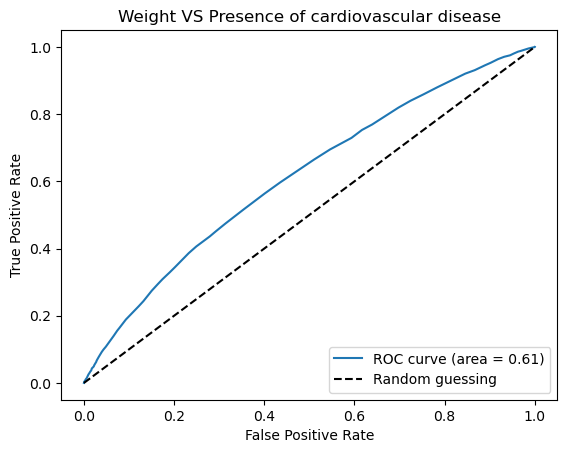

In [20]:
# Split data into training and testing sets
X = df[['weight']]
y = df['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit a logistic regression model to the training data
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

print('Intercept \t: b = ', logreg.intercept_)
print('Coefficients \t: a = ', logreg.coef_ ,'\n')

# Predict the target variable on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the performance of the model on the testing data
print(classification_report(y_test, y_pred))
print('AUC-ROC:', roc_auc_score(y_test, logreg.predict_proba(X_test)[:,1]))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Predict probabilities for testing set
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

# Compute false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute area under ROC curve
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Weight VS Presence of cardiovascular disease')
plt.legend(loc="lower right")
plt.show()

Intercept 	: b =  [-2.06403612]
Coefficients 	: a =  [[0.07508233]] 

              precision    recall  f1-score   support

       False       0.58      0.68      0.62     10461
        True       0.61      0.51      0.55     10539

    accuracy                           0.59     21000
   macro avg       0.59      0.59      0.59     21000
weighted avg       0.59      0.59      0.59     21000

AUC-ROC: 0.6222685530201283
Accuracy: 0.5903333333333334


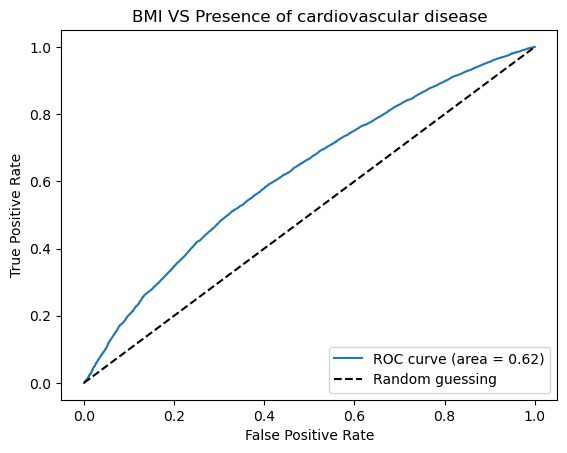

In [32]:
# Split data into training and testing sets
X = df[['bmi']]
y = df['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit a logistic regression model to the training data
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

print('Intercept \t: b = ', logreg.intercept_)
print('Coefficients \t: a = ', logreg.coef_ ,'\n')

# Predict the target variable on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the performance of the model on the testing data
print(classification_report(y_test, y_pred))
print('AUC-ROC:', roc_auc_score(y_test, logreg.predict_proba(X_test)[:,1]))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Predict probabilities for testing set
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

# Compute false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute area under ROC curve
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BMI VS Presence of cardiovascular disease')
plt.legend(loc="lower right")
plt.show()

Intercept 	: b =  [-7.98442203]
Coefficients 	: a =  [[0.0633133]] 

              precision    recall  f1-score   support

       False       0.68      0.80      0.74     10461
        True       0.76      0.63      0.69     10539

    accuracy                           0.72     21000
   macro avg       0.72      0.72      0.72     21000
weighted avg       0.72      0.72      0.72     21000

AUC-ROC: 0.7551056917528993
Accuracy: 0.7177619047619047


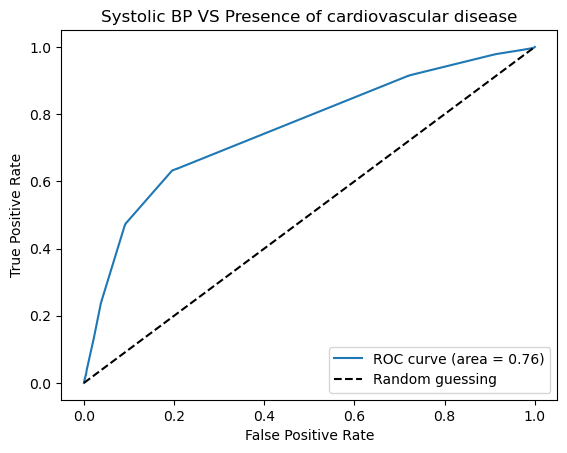

In [34]:
# Split data into training and testing sets
X = df[['ap_hi']]
y = df['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit a logistic regression model to the training data
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

print('Intercept \t: b = ', logreg.intercept_)
print('Coefficients \t: a = ', logreg.coef_ ,'\n')

# Predict the target variable on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the performance of the model on the testing data
print(classification_report(y_test, y_pred))
print('AUC-ROC:', roc_auc_score(y_test, logreg.predict_proba(X_test)[:,1]))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Predict probabilities for testing set
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

# Compute false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute area under ROC curve
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Systolic BP VS Presence of cardiovascular disease')
plt.legend(loc="lower right")
plt.show()

Intercept 	: b =  [-5.35658956]
Coefficients 	: a =  [[0.06549289]] 

              precision    recall  f1-score   support

       False       0.62      0.86      0.72     10461
        True       0.77      0.47      0.58     10539

    accuracy                           0.66     21000
   macro avg       0.69      0.66      0.65     21000
weighted avg       0.70      0.66      0.65     21000

AUC-ROC: 0.6969216418849643
Accuracy: 0.663952380952381


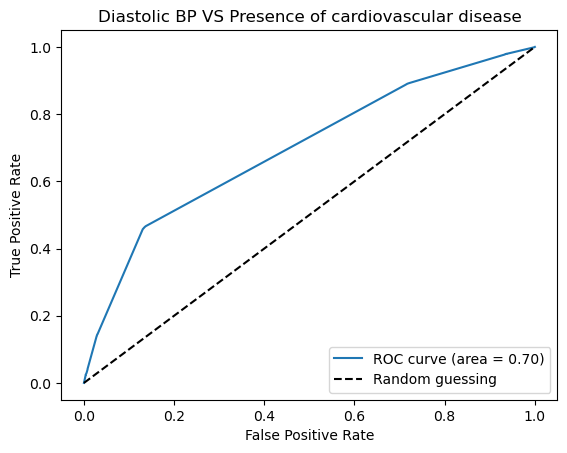

In [36]:
# Split data into training and testing sets
X = df[['ap_lo']]
y = df['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit a logistic regression model to the training data
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

print('Intercept \t: b = ', logreg.intercept_)
print('Coefficients \t: a = ', logreg.coef_ ,'\n')

# Predict the target variable on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the performance of the model on the testing data
print(classification_report(y_test, y_pred))
print('AUC-ROC:', roc_auc_score(y_test, logreg.predict_proba(X_test)[:,1]))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Predict probabilities for testing set
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

# Compute false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute area under ROC curve
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Diastolic BP VS Presence of cardiovascular disease')
plt.legend(loc="lower right")
plt.show()

Intercept 	: b =  [1.85724915]
Coefficients 	: a =  [[-0.70268247]] 

              precision    recall  f1-score   support

       False       0.56      0.84      0.67     10461
        True       0.68      0.33      0.45     10539

    accuracy                           0.59     21000
   macro avg       0.62      0.59      0.56     21000
weighted avg       0.62      0.59      0.56     21000

AUC-ROC: 0.5920792022899471
Accuracy: 0.5861904761904762


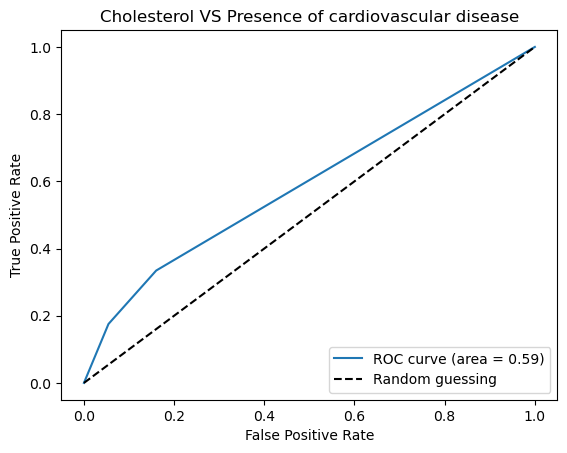

In [71]:
# Split data into training and testing sets
X = df[['cholesterol']]
y = df['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit a logistic regression model to the training data
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

print('Intercept \t: b = ', logreg.intercept_)
print('Coefficients \t: a = ', logreg.coef_ ,'\n')

# Predict the target variable on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the performance of the model on the testing data
print(classification_report(y_test, y_pred))
print('AUC-ROC:', roc_auc_score(y_test, logreg.predict_proba(X_test)[:,1]))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Predict probabilities for testing set
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

# Compute false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute area under ROC curve
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cholesterol VS Presence of cardiovascular disease')
plt.legend(loc="lower right")
plt.show()

Intercept 	: b =  [-0.40385258]
Coefficients 	: a =  [[0.32654458]] 

              precision    recall  f1-score   support

       False       0.52      0.88      0.65     10461
        True       0.60      0.18      0.28     10539

    accuracy                           0.53     21000
   macro avg       0.56      0.53      0.47     21000
weighted avg       0.56      0.53      0.46     21000

AUC-ROC: 0.5312173059548513
Accuracy: 0.5296190476190477


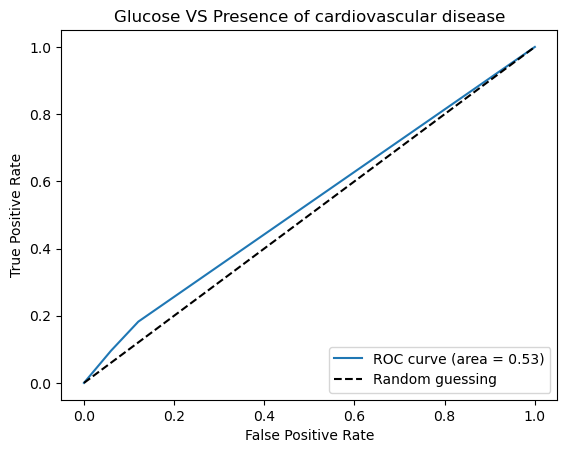

In [79]:
# Split data into training and testing sets
X = df[['gluc']]
y = df['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit a logistic regression model to the training data
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

print('Intercept \t: b = ', logreg.intercept_)
print('Coefficients \t: a = ', logreg.coef_ ,'\n')

# Predict the target variable on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the performance of the model on the testing data
print(classification_report(y_test, y_pred))
print('AUC-ROC:', roc_auc_score(y_test, logreg.predict_proba(X_test)[:,1]))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Predict probabilities for testing set
y_pred_prob = logreg.predict_proba(X_test)[:, 1]

# Compute false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Compute area under ROC curve
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Glucose VS Presence of cardiovascular disease')
plt.legend(loc="lower right")
plt.show()

# Random Forest

In [13]:
# Train
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Predict
y_pred_rf = rf.predict(X_test_scaled)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.7123571428571429
              precision    recall  f1-score   support

       False       0.71      0.72      0.71      6988
        True       0.72      0.71      0.71      7012

    accuracy                           0.71     14000
   macro avg       0.71      0.71      0.71     14000
weighted avg       0.71      0.71      0.71     14000

Confusion Matrix:
 [[5023 1965]
 [2062 4950]]


#  Feature Importance (Random Forest)

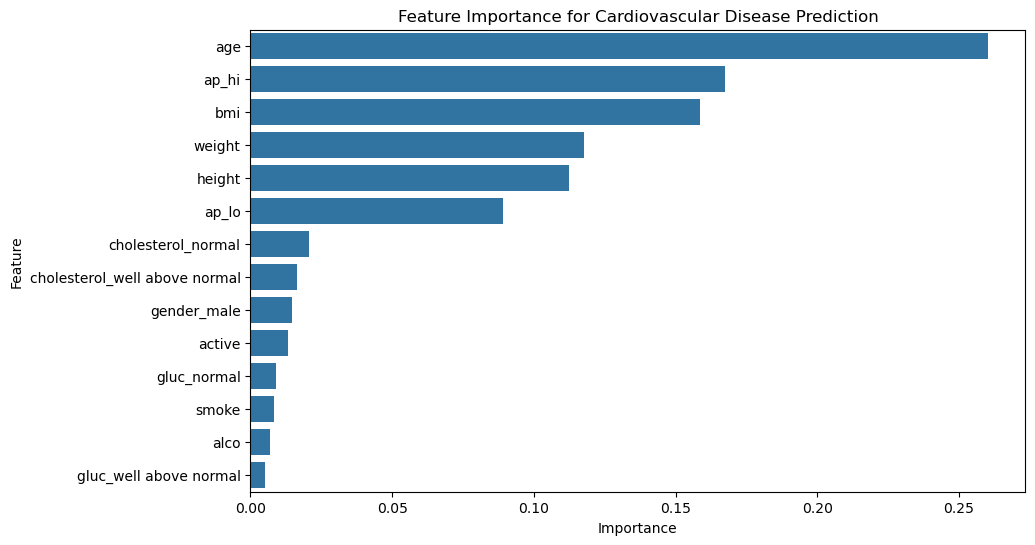

In [15]:
# Plot feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance for Cardiovascular Disease Prediction')
plt.show()